In [1]:
from Scripts.Random_forest_nested import *
import matplotlib.pyplot as plt
import pickle 
from scipy.stats import randint
import seaborn as sns
import numpy as np
import shap
import pandas as pd

In [2]:
df = pd.read_excel('../Data_preprocessing/all_time.xlsx', index_col=0)
X,y=df.loc[:,['scaled_nox','scaled_no2','scaled_formaldehyd','scaled_acetone','scaled_acetald',
    'scaled_bc', 'scaled_PM25','no2_street', 'nox_street', 'pm25_street', 'gestational_age', 'lrti_1y',
       'genetic_risk_score_asthma']],df.verificeret_18y

In [3]:
list_parameters=[r'$\mathbf{NO_x}$',r'$\mathbf{NO_2}$',"Formaldehyd","Acetone","Acetald","Black Carbon",r'$\mathbf{PM_{2.5}}$',r"$\mathbf{Street \ NO_2}$",r"$\mathbf{Street \ NO_x}$",r"$\mathbf{Street \ PM_{2.5}}$","Gestational age","PRS",'LRTI']

In [4]:
replace_dict=dict(zip(X.columns,list_parameters))
X=X.rename(columns=replace_dict)

In [5]:
param_distributions = {
    'n_estimators':           [300],
    'max_depth':              randint(2, 6),
    'min_samples_leaf':       randint(5, 15),
    'max_features':           [0.5, 0.6, 0.7],
    'max_samples':            [0.5, 0.6, 0.7],
    # class_weight removed
}
dataframe=nested_cv_calibrated_rf(
    X, y,
    n_repeats=5,
    n_splits=5,
    n_neighbors_imputer=25,
    param_distributions=param_distributions)

fold   1/25  test AUC=0.229  BSS=-0.010  ICI=0.155   | apparent AUC=0.128
fold   2/25  test AUC=0.474  BSS=-0.031  ICI=0.092   | apparent AUC=0.946
fold   3/25  test AUC=0.621  BSS=+0.015  ICI=0.051   | apparent AUC=0.799
fold   4/25  test AUC=0.650  BSS=+0.025  ICI=0.055   | apparent AUC=0.824
fold   5/25  test AUC=0.519  BSS=-0.010  ICI=0.050   | apparent AUC=0.814
fold   6/25  test AUC=0.619  BSS=+0.015  ICI=0.056   | apparent AUC=0.804
fold   7/25  test AUC=0.538  BSS=+0.004  ICI=0.022   | apparent AUC=0.913
fold   8/25  test AUC=0.509  BSS=-0.007  ICI=0.058   | apparent AUC=0.864
fold   9/25  test AUC=0.673  BSS=+0.029  ICI=0.072   | apparent AUC=0.793
fold  10/25  test AUC=0.517  BSS=+0.000  ICI=0.057   | apparent AUC=0.920
fold  11/25  test AUC=0.618  BSS=+0.019  ICI=0.048   | apparent AUC=0.901
fold  12/25  test AUC=0.541  BSS=+0.006  ICI=0.026   | apparent AUC=0.877
fold  13/25  test AUC=0.674  BSS=+0.049  ICI=0.057   | apparent AUC=0.913


/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/data/michaelf/miniconda3/envs/clinical_regression/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

fold  14/25  test AUC=0.525  BSS=-0.014  ICI=0.049   | apparent AUC=0.842
fold  15/25  test AUC=0.644  BSS=+0.032  ICI=0.059   | apparent AUC=0.909
fold  16/25  test AUC=0.539  BSS=-0.002  ICI=0.043   | apparent AUC=0.886
fold  17/25  test AUC=0.690  BSS=+0.051  ICI=0.061   | apparent AUC=0.789
fold  18/25  test AUC=0.592  BSS=+0.004  ICI=0.055   | apparent AUC=0.860
fold  19/25  test AUC=0.554  BSS=-0.007  ICI=0.064   | apparent AUC=0.802
fold  20/25  test AUC=0.702  BSS=+0.049  ICI=0.089   | apparent AUC=0.910
fold  21/25  test AUC=0.581  BSS=+0.009  ICI=0.044   | apparent AUC=0.949
fold  22/25  test AUC=0.742  BSS=+0.062  ICI=0.108   | apparent AUC=0.895
fold  23/25  test AUC=0.647  BSS=+0.023  ICI=0.062   | apparent AUC=0.888
fold  24/25  test AUC=0.613  BSS=+0.016  ICI=0.029   | apparent AUC=0.864
fold  25/25  test AUC=0.538  BSS=-0.003  ICI=0.063   | apparent AUC=0.803


In [8]:
with open("../Performence/results_rf_18y.pkl", "wb") as f:
    pickle.dump(dataframe, f)

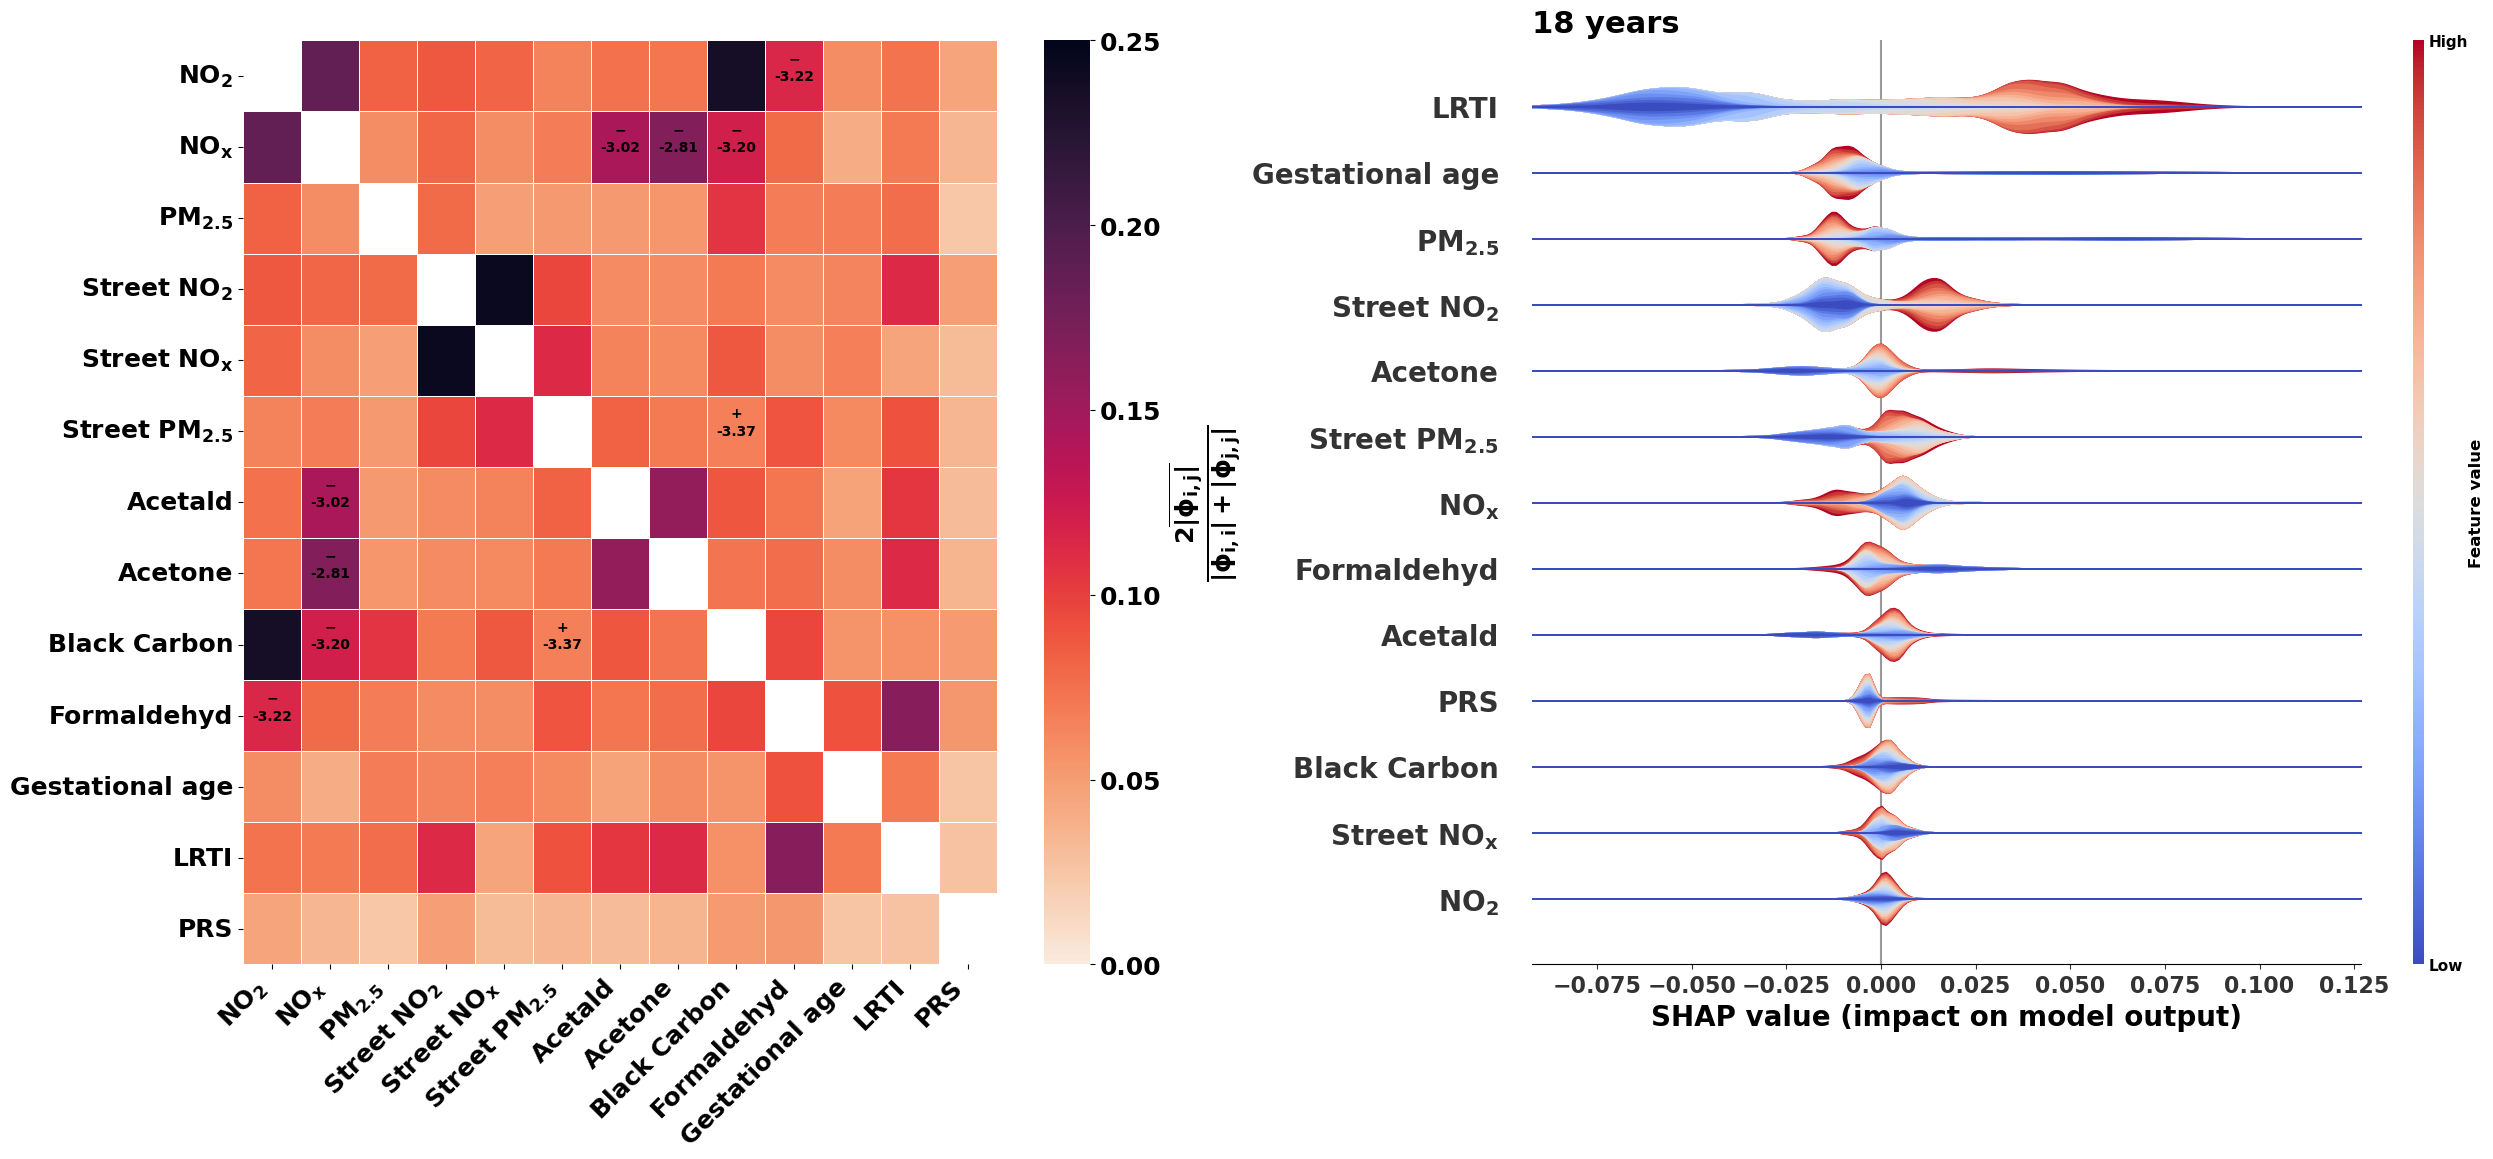

In [9]:

# Swap the columns to create the reverse relationships (B->A, C->A, C->B)
df_flipped = dataframe["interaction_stats"].rename(columns={'feature_i': 'feature_j', 'feature_j': 'feature_i'})

# Combine them together
df_full = pd.concat([dataframe["interaction_stats"], df_flipped]).drop_duplicates()
features_to_drop = ["feature_i", "feature_j"]

matrix_r = df_full.pivot(index='feature_i', columns='feature_j', values='R_mean').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_con = df_full.pivot(index='feature_i', columns='feature_j', values='sign_consistency').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect = df_full.pivot(index='feature_i', columns='feature_j', values='abs_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
matrix_effect_sign = df_full.pivot(index='feature_i', columns='feature_j', values='signed_2phi_median').rename_axis(None, axis=0).rename_axis(None, axis=1)
dominant_sign= df_full.pivot(index='feature_i', columns='feature_j', values='dominant_sign').rename_axis(None, axis=0).rename_axis(None, axis=1)
plt.rcParams.update({
    "mathtext.default":  "bf",
    "font.weight":       "bold",
    "axes.labelweight":  "bold",
    "axes.titleweight":  "bold",
    "figure.titleweight":"bold",
})

k = matrix_r.shape[0]
corr_matrix=X.corr(method="spearman")

fig = plt.figure(figsize=(30, 12))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.1], wspace=0.35)
ax0, ax1 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

hm = sns.heatmap(matrix_r, cmap="rocket_r", vmin=0, vmax=0.25,
                 linewidths=0.4, linecolor="white", ax=ax0,
                 cbar_kws={'label': r'$\frac{2\overline{|\phi_{i,j}|}}{|\phi_{i,i}|+|\phi_{j,j}|}$'})

norm, cmap = hm.collections[0].norm, hm.collections[0].cmap
for i in range(k):
    for j in range(k):                            # lower triangle only
        if matrix_con.iloc[i, j] < 0.8:
            continue
        if i==j:
            continue
        if np.abs(corr_matrix.loc[matrix_con.columns[i],matrix_con.columns[j]])>0.3:
            continue     
        val = matrix_effect.iloc[i, j]
        sgn = "+" if dominant_sign.iloc[i, j] >= 0 else "\u2212"
        r, g, b, _ = cmap(norm(matrix_r.iloc[i, j]))
        ax0.text(j + 0.5, i + 0.5, f"{np.log10(val):.2f}", ha="center", va="center",  fontsize=10, fontweight="bold")
        ax0.text(j + 0.5, i + 0.25, f"{sgn}", ha="center", va="center",
                 fontsize=10, fontweight="bold")      

# ---- heatmap ticks ----
ax0.tick_params(axis="both", labelsize=18)
plt.setp(ax0.get_xticklabels(), rotation=45, ha="right", fontsize=18, fontweight="bold")
plt.setp(ax0.get_yticklabels(), fontsize=18, fontweight="bold")

# ---- colorbar ----
cbar = hm.collections[0].colorbar
cbar.ax.yaxis.label.set(size=26, weight="bold")
cbar.ax.tick_params(labelsize=18)
plt.setp(cbar.ax.get_yticklabels(), fontweight="bold")

# ---- shap panel ----
plt.sca(ax1)
shap.plots.violin(dataframe["shap_explanation"],
                  plot_type="layered_violin",
                  max_display=15, show=False, plot_size=None)
ax1.tick_params(axis="y", labelsize=20)
ax1.tick_params(axis="x", labelsize=16)
plt.setp(ax1.get_yticklabels(), fontsize=20, fontweight="bold")
plt.setp(ax1.get_xticklabels(), fontsize=16, fontweight="bold")
ax1.set_xlabel(ax1.get_xlabel(), fontsize=20, fontweight="bold")
ax1.set_title("18 years", loc="left", fontsize=22, pad=6, fontweight="bold")

fig.savefig("../Plots/shap_18.png", bbox_inches="tight",dpi=300)  

In [19]:
dataframe['fold_metrics'].bss_test.mean()


np.float64(0.012886762153556615)